# Aufgabe 3

# Bestimmen der Präzessionsfrequenz in Abhängigkeit von der Rotationsfrequenz

Bei der dritten Aufgabe wurde während der Drehung eine Masse an das Ende der Scheibe gehängt und dadurch wurde Präzession beobachtet. Die Zeit für eine halbe Umdrehung der Präzession wurde für verschiedene Rotationsfrequenzen und Massen gemessen. Ausgehend davon, soll der Wert $I_3$ des Trägheitsmomenttensors bestimmt werden.

Wir beginnen, indem wir unsere gemessenen Daten umwandeln. Bei der Rotationsgeschwindigkeit wurde der Mittelwert aus dem Startwert und dem Wert nach einer halben Präzessionsumdrehung genutzt:
| Mittelwert Rotationsgeschwindigkeit [RPM] | Präzessionszeit t [s] | Masse m [g] |
|------------------------------------------|------------------------|-------------|
| 2500                                     | 7.6                    | 47          |
| 1743                                     | 5.53                   | 47          |
| 2256                                     | 7.09                   | 47          |
| 2679                                     | 7.97                   | 47          |
| 3100                                     | 9.75                   | 47          |
| 2895                                     | 7.94                   | 47          |
| 2200                                     | 3.78                   | 94          |
| 2306                                     | 3.94                   | 94          |
| 3252                                     | 4.28                   | 94          |
| 2883                                     | 5.00                   | 94          |
| 1577                                     | 2.62                   | 94          |
| 2228                                     | 2.56                   | 94          |
| 2312                                     | 3.03                   | 94          |
| 2183                                     | 4.22                   | 94          |

Um die Rotationsgeschindigkeit in die Rotationsfrequenz umzuwandeln, müssen wir erstmal durch 8 teilen, da wir 8 Reflektoren hatten und somit immer nur $\frac{1}{8}$ Umdrehungen gemessen wurden. Dann auch noch durch 60, damit wir pro Sekunde haben. Da in unserer Rechnung später $\frac{1}{\omega}$ gesucht wird und wir bisher nur f haben. nutzen wir auch noch die Formel: $\frac{1}{\omega} = \frac{1}{2\pi f}$. Für die Präzessions müssen wir $\frac{2\cdot \pi}{2t}$ rechnen. da wir nur eine halbe Umdrehung haben und $T = \frac{1}{f}$ gilt.

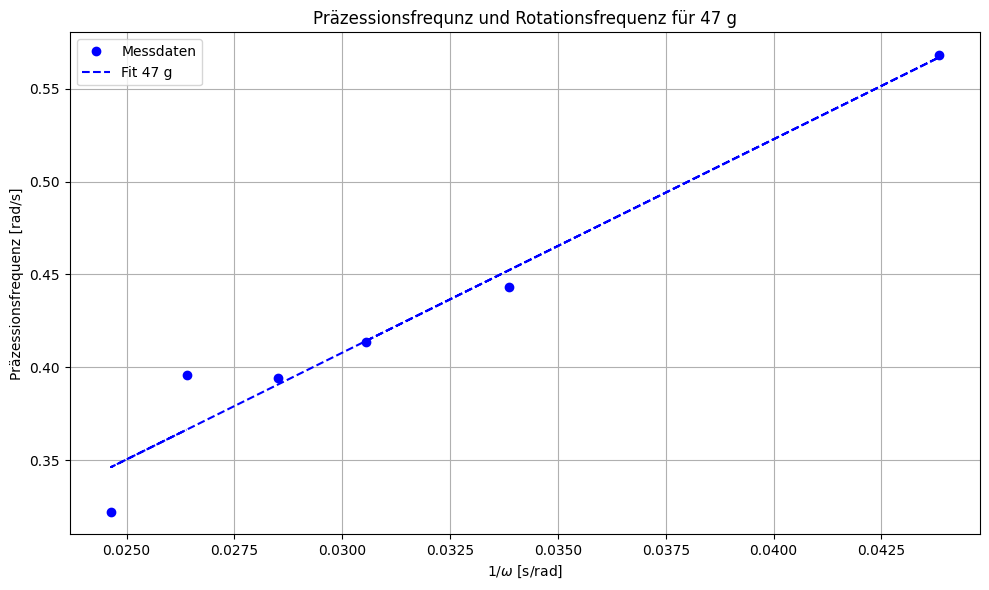

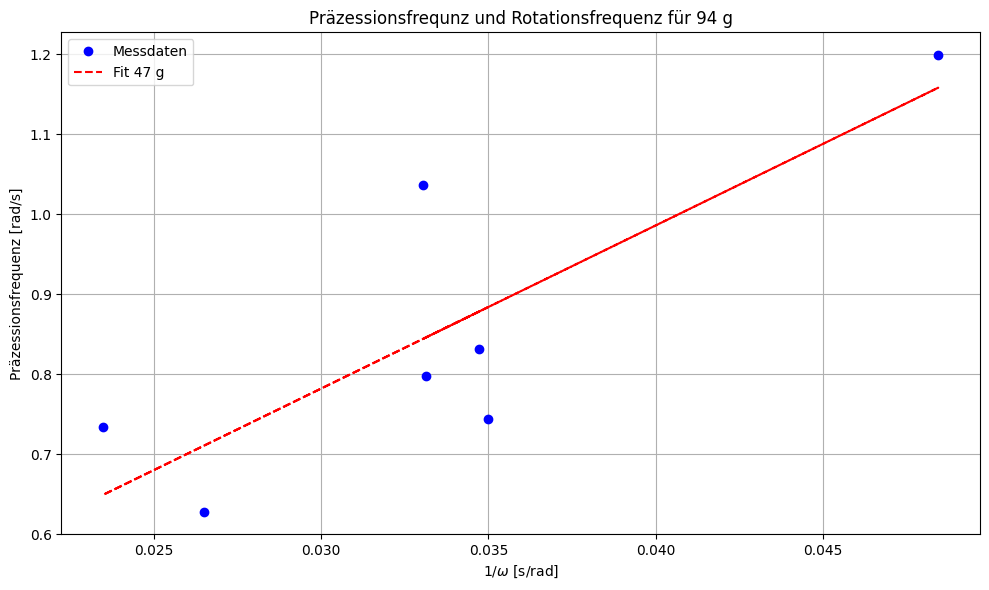

Steigung 47 g: 11.494811020583002
Steigung 94 g: 20.40283755369257


In [ ]:
# | fig-cap:
# |     - Präzessionsfrequnz und Rotationsfrequenz für 47 g
# |     - Präzessionsfrequnz und Rotationsfrequenz für 94 g
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df = pd.read_csv('Daten/Aufgabe_3_vorher.csv')
df.columns = ['RPM_vor','t [s]','m[g]']

df['RPM_vor'] = df['RPM_vor']/(8*60)  # Umrechnung von RPM in Umdrehungen pro Sekunde
df['RPM_vor'] = 1/ (df['RPM_vor'] * 2 * np.pi)  # Umrechnung in rad/s
df['t [s]'] = 2 * np.pi / (2 * df['t [s]'])



df1 = df[df['m[g]'] == 47]
df2 = df[df['m[g]'] == 94]
# print(df)
# print(df1)
# print(df2)

fit_df1 = np.polyfit(df1['RPM_vor'], df1['t [s]'], 1)
fit_df2 = np.polyfit(df2['RPM_vor'], df2['t [s]'], 1)

# Plot für die Messdaten
plt.figure(figsize=(10, 6))
plt.plot(df1['RPM_vor'],df1['t [s]'],'o', label="Messdaten", color="blue",)
plt.plot(df1['RPM_vor'], np.polyval(fit_df1, df1['RPM_vor']), label="Fit 47 g", color="blue", linestyle='--')
plt.ylabel("Präzessionsfrequenz [rad/s]")
plt.xlabel(r"1/$\omega$ [s/rad]")
plt.title("Präzessionsfrequnz und Rotationsfrequenz für 47 g")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot für die Messdaten
plt.figure(figsize=(10, 6))
plt.plot(df2['RPM_vor'],df2['t [s]'],'o', label="Messdaten", color="blue".)
plt.plot(df2['RPM_vor']. np.polyval(fit_df2, df2['RPM_vor']), label="Fit 47 g", color="red", linestyle='--')
plt.ylabel("Präzessionsfrequenz [rad/s]")
plt.xlabel(r"1/$\omega$ [s/rad]")
plt.title("Präzessionsfrequnz und Rotationsfrequenz für 94 g")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print('Steigung 47 g:', fit_df1[0])
print('Steigung 94 g:', fit_df2[0])


Zum berechnen des Trägheitsmoment nutzen wir die Formeln aus dem Aufgaben PDF. Betrachten wir zuerst Gleichung (12): $|L| = \sqrt{(I_1\Omega_p)^2+(I_3\omega_3)^2}$.
Da $\Omega_p << \omega_3$, können wir das nähern mit $|L| = I_3\omega_3$ und für den Drehmoment gilt $M = m_z \cdot g \cdot z_z$. Dabei ist $m_z$ die angehängte Masse und $z_z$ ist der Abstand vom Gewicht zur Kreiselachse. Setzen wir das in Gleichung (9) ein folgt:
$$\Omega_p = \frac{M}{L} = \frac{M}{I_3\omega_3} \Rightarrow \Omega_p = \frac{m_z \cdot g \cdot z_z}{I_3\omega_3} \Rightarrow \Omega_p = \left(\frac{m_zgz_z}{I_3}\right) \cdot \frac{1}{\omega_3}$$ 
Um $I_3$ zu berechnen. nutzen wir also die Steigung des fits:
$$I_3 = \frac{m_zgz_z}{\text{Steigung}}$$
Bei unserem Aufbau hatten wir g = 9.81 $\frac{m}{s^2}$ und $z_z = 275mm = 0.275m$

Für $m_z = 0.047kg$ haben wir eine Steigung von 11.49. Also $$I_3 = \frac{0.047kg \cdot 9.81 \frac{m}{s^2} \cdot 0.275m}{11.49} = 0.011kg \cdot m^2$$
und für $m_z = 0.094kg$ haben wir eine Steigung von 20.40. Also $$I_3 = \frac{0.094kg \cdot 9.81 \frac{m}{s^2} \cdot 0.275m}{20.40} = 0.0124 \pm 0.0007 kg \cdot m^2$$

Die Ergebnisse sind sehr ähnlich zu den in 1 berechneten und liegen sehr nahe am theoretischen Wert von $I_3 = 0.0117 kg \cdot m^2$


## Fehlerbetrachtung
Bei den Messungen für diese Aufgabe gab es sehr große Fehlerquellen. da sich der Kreisel bewegt hatte. konnte man nicht immer enau die Rotationszeit bestimmen, da die Oberfläche der Kreisscheibe nicht immer genau parallel zu dem Laser war. Zudem da das Messgerät in der Hand gehalten wurdey kam es auch bem Messgerät zu Bewegungen, welche drastisch die Zahl der Umdrehungen beeinflussen könnte.